### # Sentence Similarity with TF-IDF, Word2Vec, and BERT

This notebook compares **three** common text-embedding approaches—**TF-IDF**, **Word2Vec**, and **BERT**—by visualizing how each one captures sentence-level similarity. Starting with a toy corpus of three short sentences, we:

1. use `TfidfVectorizer` to build classic bag-of-words vectors that rely on token frequency and inverse document frequency;
2. load pre-trained **Google-News Word2Vec** embeddings and represent each sentence by the mean of its constituent word vectors, capturing distributional semantics;
3. extract dense, contextualized embeddings from the **\[CLS] token** of `bert-base-uncased`, which summarizes sentence meaning in a transformer.

For all three representations we compute cosine-similarity matrices, then render them as side-by-side heatmaps with Matplotlib. The visual comparison makes clear how TF-IDF reflects surface word overlap, Word2Vec introduces basic semantic information through averaged word vectors, and BERT captures deeper contextual meaning—even when the sentences share few exact tokens.



⌛ downloading Google-News Word2Vec (first run only)…
[==================================================] 100.0% 1662.8/1662.8MB downloaded


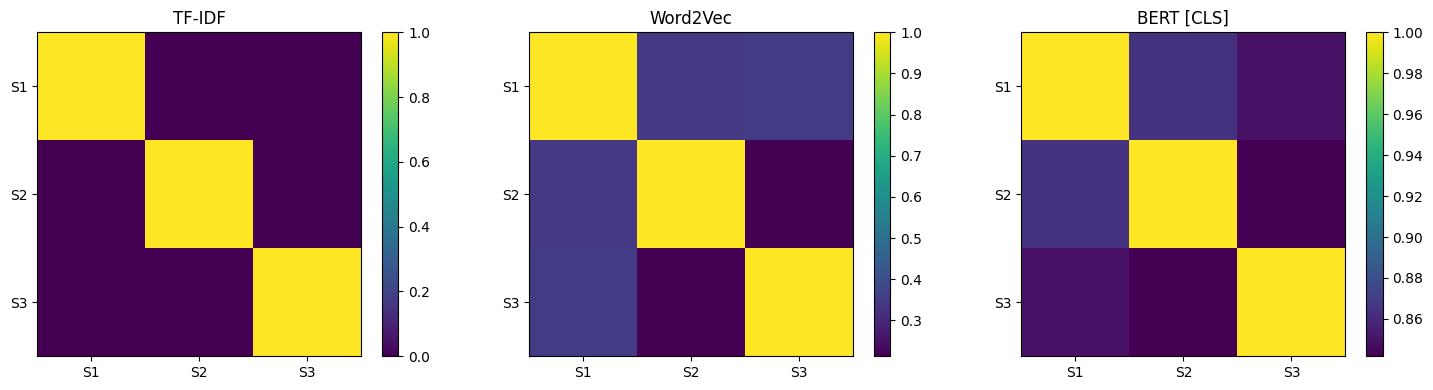

In [ ]:
import numpy as np, matplotlib.pyplot as plt, torch
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from transformers import AutoTokenizer, AutoModel
import gensim.downloader as api # word2vec

# Toy corpus
sentences = [
    "I love learning about natural language processing.",
    "TF-IDF is a classic baseline for text similarity.",
    "Transformers like BERT have revolutionized NLP."
]
labels = [f"S{i+1}" for i in range(len(sentences))]

# TF-IDF sentence vectors
tfidf = TfidfVectorizer()
tfidf_vecs = tfidf.fit_transform(sentences).toarray()
sim_tfidf  = cosine_similarity(tfidf_vecs)

# Word2Vec sentence vectors (mean of word vectors)
print("⌛ downloading Google-News Word2Vec…")
w2v = api.load("word2vec-google-news-300")

def sent_w2v(text):
    words = [w for w in text.lower().split() if w in w2v.key_to_index]
    return np.mean([w2v[w] for w in words], axis=0) if words else np.zeros(300)

w2v_vecs = np.vstack([sent_w2v(s) for s in sentences])
sim_w2v  = cosine_similarity(w2v_vecs)

# 4) BERT sentence vectors
tok  = AutoTokenizer.from_pretrained("bert-base-uncased")
bert = AutoModel.from_pretrained("bert-base-uncased")

# This function computes the [CLS] token embedding for a sentence
# which is often used as a sentence representation in BERT.
@torch.no_grad()
def cls_embed(text):
    out = bert(**tok(text, return_tensors="pt", truncation=True))
    return out.last_hidden_state[:, 0, :].squeeze().cpu().numpy()

# Ensure BERT is in evaluation mode
bert_vecs = np.vstack([cls_embed(s) for s in sentences])
sim_bert  = cosine_similarity(bert_vecs)

# Heat-map visualization of the similarity matrices
def heatmap(mat, title, idx):
    plt.subplot(1, 3, idx)
    plt.imshow(mat, interpolation="nearest")
    plt.title(title)
    plt.colorbar(fraction=0.046)
    plt.xticks(range(len(sentences)), labels)
    plt.yticks(range(len(sentences)), labels)

plt.figure(figsize=(15, 4))
heatmap(sim_tfidf, "TF-IDF", 1)
heatmap(sim_w2v , "Word2Vec", 2)
heatmap(sim_bert , "BERT [CLS]", 3)
plt.tight_layout()
plt.show()
